In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("diamonds.csv")
print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [11]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

Shape: (53940, 11)

Columns:
Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [12]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [13]:
print(df.isnull().sum())

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


In [14]:
df.fillna(method="ffill", inplace=True)

print("Missing values handled.")

Missing values handled.


/tmp/ipykernel_3195/2681425622.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [15]:
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates Removed")

Duplicate Rows: 0
Duplicates Removed


In [16]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode().iloc[0])

print("\nVariance")
print(df.var(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean
Unnamed: 0    26970.500000
carat             0.797940
depth            61.749405
table            57.457184
price          3932.799722
x                 5.731157
y                 5.734526
z                 3.538734
dtype: float64

Median
Unnamed: 0    26970.50
carat             0.70
depth            61.80
table            57.00
price          2401.00
x                 5.70
y                 5.71
z                 3.53
dtype: float64

Mode
Unnamed: 0        1
carat           0.3
cut           Ideal
color             G
clarity         SI1
depth          62.0
table          56.0
price         605.0
x              4.37
y              4.34
z               2.7
Name: 0, dtype: object

Variance
Unnamed: 0    2.424648e+08
carat         2.246867e-01
depth         2.052404e+00
table         4.992948e+00
price         1.591563e+07
x             1.258347e+00
y             1.304472e+00
z             4.980109e-01
dtype: float64

Standard Deviation
Unnamed: 0    15571.281097
carat             0.

In [17]:
numeric_cols = df.select_dtypes(include=np.number)

for col in numeric_cols.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

print("Outliers treated successfully!")

Outliers treated successfully!


In [18]:
print(df["cut"].value_counts())

print(df["color"].value_counts())

print(df["clarity"].value_counts())

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


In [19]:
print(df[["carat","price","depth","table"]].describe())

              carat         price         depth         table
count  53940.000000  53940.000000  53940.000000  53940.000000
mean       0.792558   3732.145690     61.749156     57.438561
std        0.457089   3436.769344      1.270254      2.161139
min        0.200000    326.000000     58.750000     51.500000
25%        0.400000    950.000000     61.000000     56.000000
50%        0.700000   2401.000000     61.800000     57.000000
75%        1.040000   5324.250000     62.500000     59.000000
max        2.000000  11885.625000     64.750000     63.500000


In [20]:
correlation = df.corr(numeric_only=True)

print(correlation)

            Unnamed: 0     carat     depth     table     price         x  \
Unnamed: 0    1.000000 -0.391008 -0.037768 -0.105239 -0.354470 -0.406087   
carat        -0.391008  1.000000  0.021868  0.187523  0.936588  0.981862   
depth        -0.037768  0.021868  1.000000 -0.299886 -0.008726 -0.028929   
table        -0.105239  0.187523 -0.299886  1.000000  0.136891  0.198407   
price        -0.354470  0.936588 -0.008726  0.136891  1.000000  0.911965   
x            -0.406087  0.981862 -0.028929  0.198407  0.911965  1.000000   
y            -0.406931  0.981132 -0.031645  0.192469  0.913492  0.998362   
z            -0.407967  0.977447  0.089990  0.158148  0.905016  0.988231   

                   y         z  
Unnamed: 0 -0.406931 -0.407967  
carat       0.981132  0.977447  
depth      -0.031645  0.089990  
table       0.192469  0.158148  
price       0.913492  0.905016  
x           0.998362  0.988231  
y           1.000000  0.987852  
z           0.987852  1.000000  


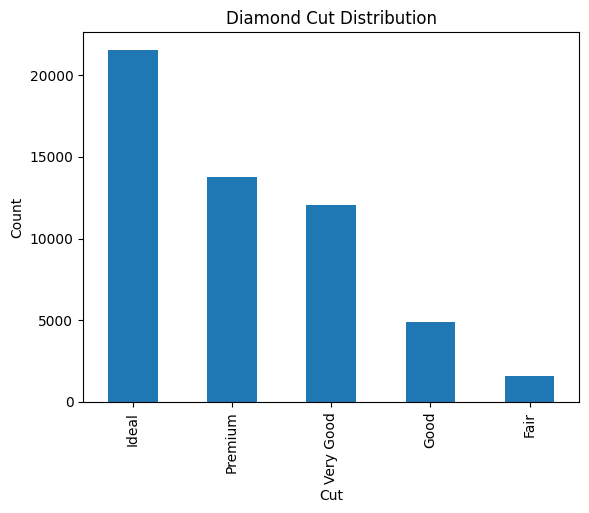

In [21]:
df["cut"].value_counts().plot(kind="bar")

plt.title("Diamond Cut Distribution")
plt.xlabel("Cut")
plt.ylabel("Count")

plt.show()

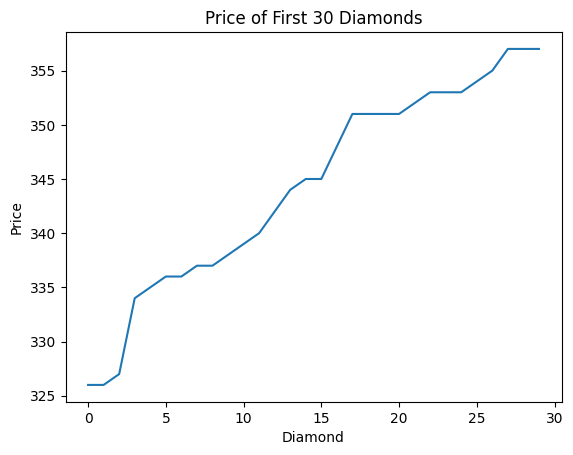

In [22]:
df["price"].head(30).plot(kind="line")

plt.title("Price of First 30 Diamonds")
plt.xlabel("Diamond")
plt.ylabel("Price")

plt.show()

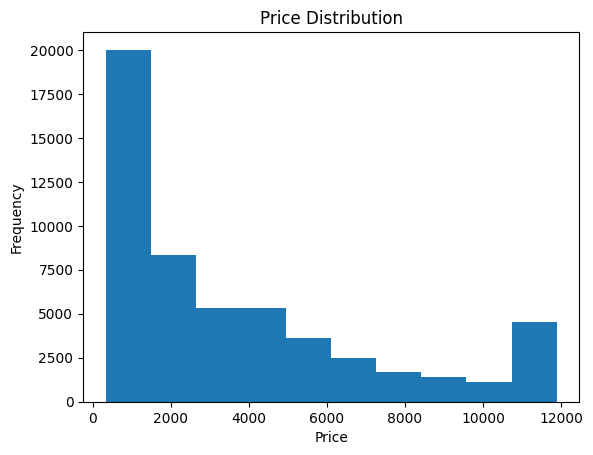

In [23]:
plt.hist(df["price"], bins=10)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

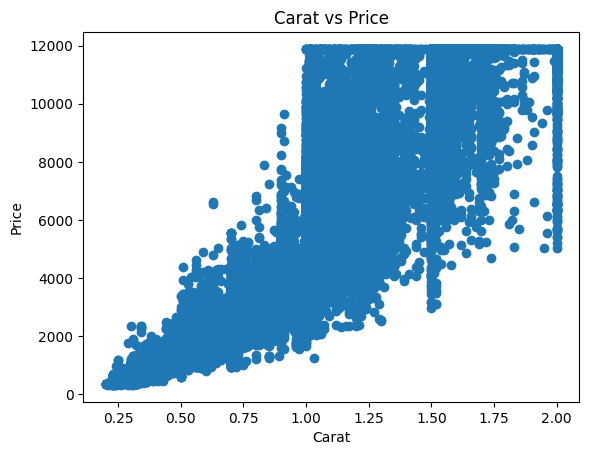

In [24]:
plt.scatter(df["carat"], df["price"])

plt.title("Carat vs Price")
plt.xlabel("Carat")
plt.ylabel("Price")

plt.show()

In [26]:
print("Business Insight Report")
print("-" * 50)
print("After analyzing the Diamonds dataset, I observed that diamond prices generally increase as carat weight increases. Premium quality cuts tend to have higher prices compared to lower quality cuts. Most diamonds fall within the average price range, while a few high-priced diamonds were identified as outliers. Data cleaning improved the quality of the dataset, making the analysis more reliable.")

Business Insight Report
--------------------------------------------------
After analyzing the Diamonds dataset, I observed that diamond prices generally increase as carat weight increases. Premium quality cuts tend to have higher prices compared to lower quality cuts. Most diamonds fall within the average price range, while a few high-priced diamonds were identified as outliers. Data cleaning improved the quality of the dataset, making the analysis more reliable.


In [27]:
print("EDA Summary")
print("-" * 50)
print("In this project, I analyzed the Diamonds dataset to understand how different features influence diamond prices. I explored the dataset, cleaned the data, handled missing values and duplicate records, detected and treated outliers, calculated statistical measures, and analyzed both categorical and numerical features. I also created different visualizations to study the relationship between carat, cut, and price. Overall, this project helped me understand data cleaning, exploratory data analysis, and data visualization using Python.")

EDA Summary
--------------------------------------------------
In this project, I analyzed the Diamonds dataset to understand how different features influence diamond prices. I explored the dataset, cleaned the data, handled missing values and duplicate records, detected and treated outliers, calculated statistical measures, and analyzed both categorical and numerical features. I also created different visualizations to study the relationship between carat, cut, and price. Overall, this project helped me understand data cleaning, exploratory data analysis, and data visualization using Python.
